In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

train.shape
test.shape

(1459, 80)

# EDA Block

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [6]:
train.isna().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

In [7]:
num_cols = train.select_dtypes(include=["int64", "float64"]).columns
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [8]:
cat_cols = train.select_dtypes(include=["object", "str"]).columns
train[cat_cols].nunique().sort_values()

Street            2
Alley             2
CentralAir        2
Utilities         2
MasVnrType        3
LandSlope         3
PoolQC            3
PavedDrive        3
GarageFinish      3
BsmtQual          4
ExterQual         4
KitchenQual       4
BsmtCond          4
BsmtExposure      4
Fence             4
MiscFeature       4
LandContour       4
LotShape          4
FireplaceQu       5
Electrical        5
HeatingQC         5
GarageQual        5
GarageCond        5
MSZoning          5
LotConfig         5
BldgType          5
ExterCond         5
BsmtFinType1      6
RoofStyle         6
GarageType        6
Foundation        6
Heating           6
BsmtFinType2      6
SaleCondition     6
Functional        7
RoofMatl          8
HouseStyle        8
Condition2        8
SaleType          9
Condition1        9
Exterior1st      15
Exterior2nd      16
Neighborhood     25
dtype: int64

In [9]:
for col in cat_cols:
    print(f"\n{col}")
    print(train[col].value_counts(dropna=False).to_dict())


MSZoning
{'RL': 1151, 'RM': 218, 'FV': 65, 'RH': 16, 'C (all)': 10}

Street
{'Pave': 1454, 'Grvl': 6}

Alley
{nan: 1369, 'Grvl': 50, 'Pave': 41}

LotShape
{'Reg': 925, 'IR1': 484, 'IR2': 41, 'IR3': 10}

LandContour
{'Lvl': 1311, 'Bnk': 63, 'HLS': 50, 'Low': 36}

Utilities
{'AllPub': 1459, 'NoSeWa': 1}

LotConfig
{'Inside': 1052, 'Corner': 263, 'CulDSac': 94, 'FR2': 47, 'FR3': 4}

LandSlope
{'Gtl': 1382, 'Mod': 65, 'Sev': 13}

Neighborhood
{'NAmes': 225, 'CollgCr': 150, 'OldTown': 113, 'Edwards': 100, 'Somerst': 86, 'Gilbert': 79, 'NridgHt': 77, 'Sawyer': 74, 'NWAmes': 73, 'SawyerW': 59, 'BrkSide': 58, 'Crawfor': 51, 'Mitchel': 49, 'NoRidge': 41, 'Timber': 38, 'IDOTRR': 37, 'ClearCr': 28, 'StoneBr': 25, 'SWISU': 25, 'MeadowV': 17, 'Blmngtn': 17, 'BrDale': 16, 'Veenker': 11, 'NPkVill': 9, 'Blueste': 2}

Condition1
{'Norm': 1260, 'Feedr': 81, 'Artery': 48, 'RRAn': 26, 'PosN': 19, 'RRAe': 11, 'PosA': 8, 'RRNn': 5, 'RRNe': 2}

Condition2
{'Norm': 1445, 'Feedr': 6, 'Artery': 2, 'RRNn': 2, '

In [10]:
corr = train.select_dtypes(include=["int64", "float64"]).corr()["SalePrice"]
corr.sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

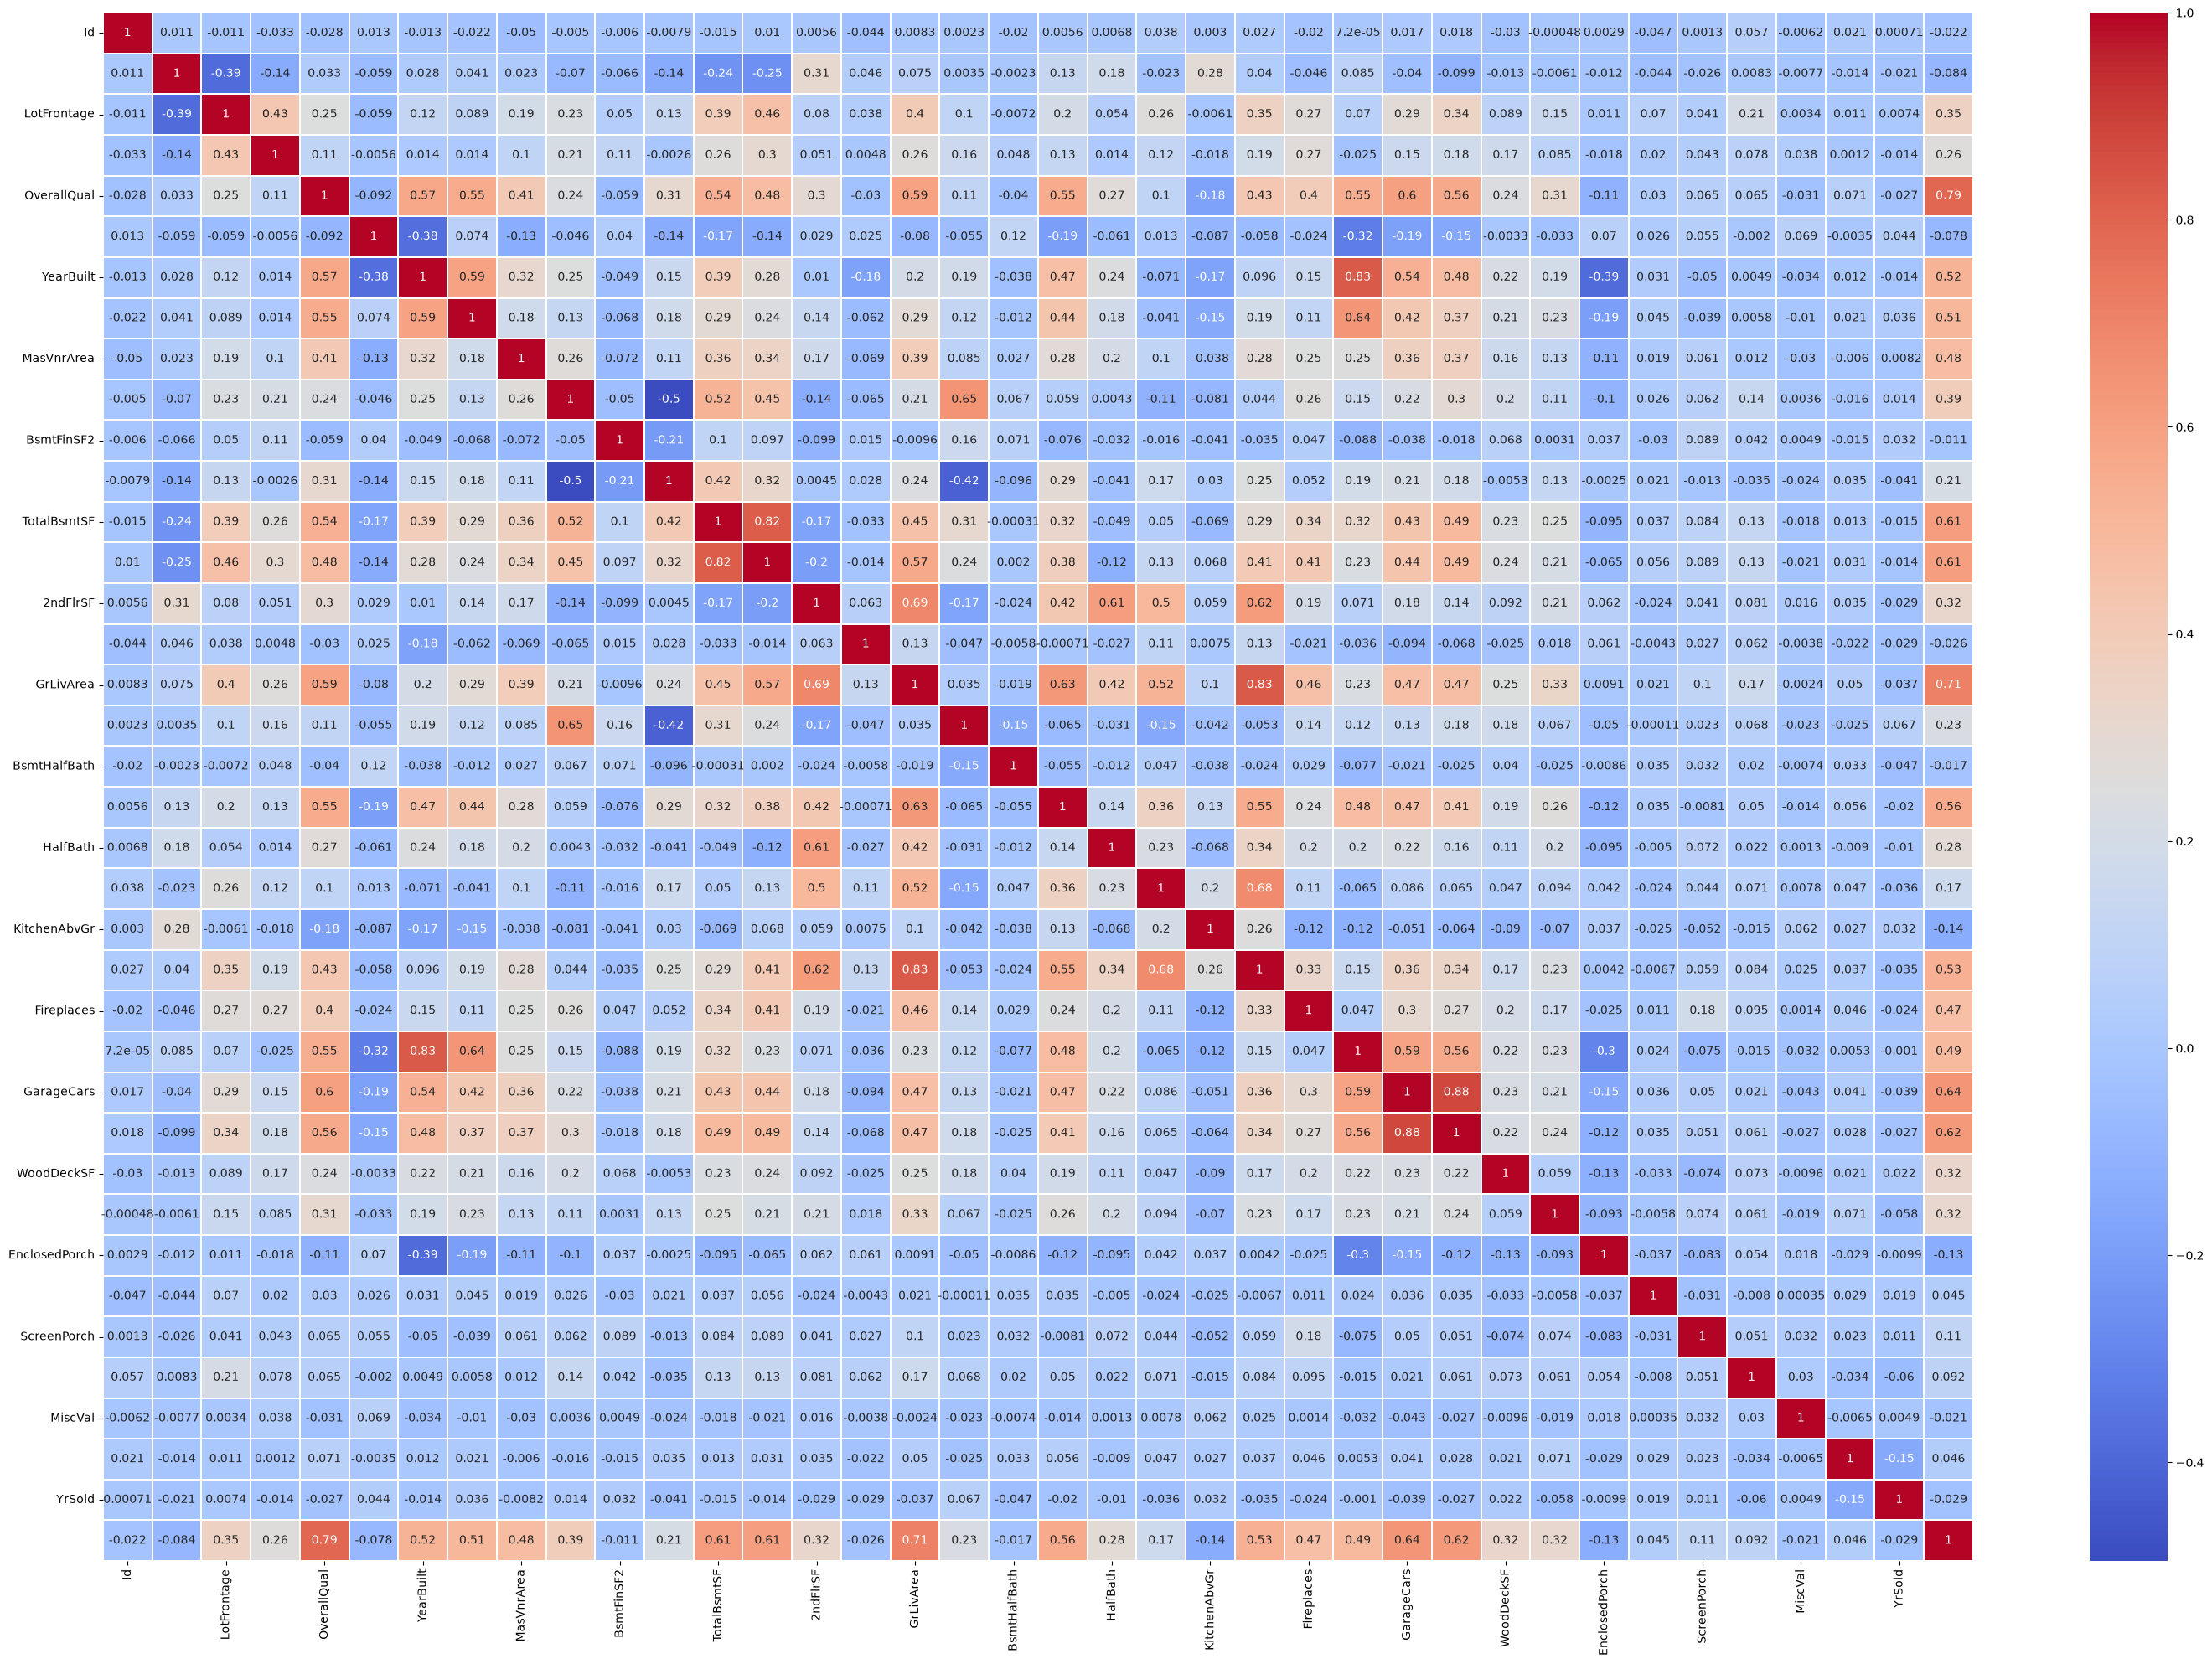

In [11]:
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(36,24)
plt.show()

In [12]:
cols =["OverallQual", "OverallCond"]
for col in cols:
    print(train.groupby(col)["SalePrice"].median())

OverallQual
1      50150.0
2      60000.0
3      86250.0
4     108000.0
5     133000.0
6     160000.0
7     200141.0
8     269750.0
9     345000.0
10    432390.0
Name: SalePrice, dtype: float64
OverallCond
1     61000.0
2     85000.0
3     89500.0
4    115000.0
5    185000.0
6    142750.0
7    145000.0
8    142500.0
9    176200.0
Name: SalePrice, dtype: float64


In [13]:
train.groupby("Neighborhood")["SalePrice"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)

,count,mean,median
Neighborhood,,,
NridgHt,77,316270.623377,315000.0
NoRidge,41,335295.317073,301500.0
StoneBr,25,310499.000000,278000.0
Timber,38,242247.447368,228475.0
Somerst,86,225379.837209,225500.0
Veenker,11,238772.727273,218000.0
Crawfor,51,210624.725490,200624.0
ClearCr,28,212565.428571,200250.0
CollgCr,150,197965.773333,197200.0


array([[<Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'LotArea'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>]], dtype=object)

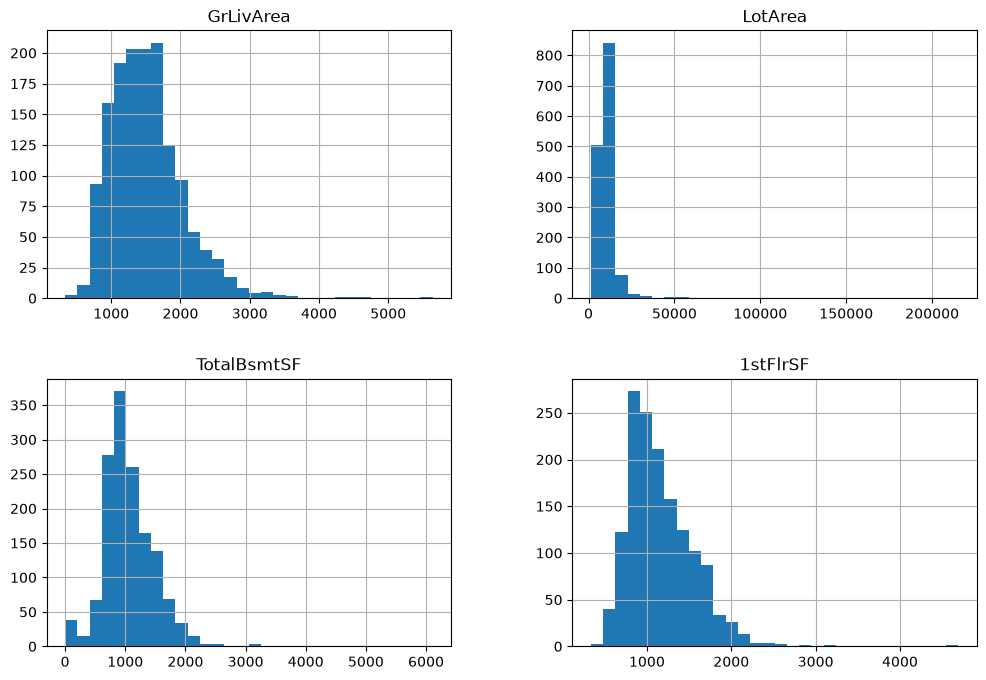

In [14]:
features = [
    "GrLivArea",
    "LotArea",
    "TotalBsmtSF",
    "1stFlrSF"
]
train[features].hist(bins=30, figsize=(12, 8))

In [15]:
train[features].skew().sort_values(ascending=False)

LotArea        12.207688
TotalBsmtSF     1.524255
1stFlrSF        1.376757
GrLivArea       1.366560
dtype: float64

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

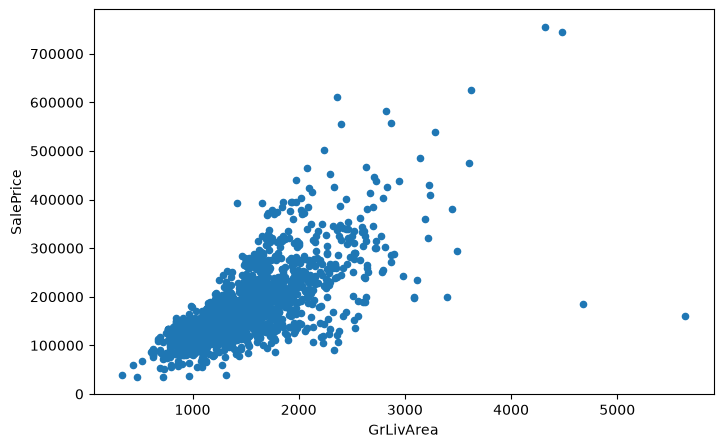

In [16]:
train.plot.scatter(
    x="GrLivArea",
    y="SalePrice",
    figsize=(8, 5)
)

In [17]:
train[train["GrLivArea"] > 3000][["GrLivArea", "OverallQual", "Neighborhood", "YearBuilt", "SalePrice"]].sort_values("GrLivArea")

,GrLivArea,OverallQual,Neighborhood,YearBuilt,SalePrice
1031,3082,7,SWISU,1920,197000
1173,3086,5,ClearCr,1946,200500
197,3112,8,NAmes,1918,235000
798,3140,9,NridgHt,2008,485000
608,3194,8,Crawfor,1934,359100
118,3222,7,SawyerW,1990,320000
496,3228,8,NoRidge,1992,430000
1353,3238,8,NoRidge,1995,410000
769,3279,8,StoneBr,2003,538000
635,3395,6,SWISU,1914,200000


In [18]:
cols = [
    "GrLivArea", "OverallQual", "OverallCond", 
    "YearBuilt", "YearRemodAdd", "Neighborhood", 
    "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", 
    "GarageCars", "GarageArea", "FullBath", 
    "BedroomAbvGr", "TotRmsAbvGrd", "SalePrice"
]
train.loc[[523, 1298], cols].T

,523,1298
GrLivArea,4676,5642
OverallQual,10,10
OverallCond,5,5
YearBuilt,2007,2008
YearRemodAdd,2008,2008
Neighborhood,Edwards,Edwards
TotalBsmtSF,3138,6110
1stFlrSF,3138,4692
2ndFlrSF,1538,950
GarageCars,3,2


In [19]:
train.loc[[523, 1298], [
    "GrLivArea", "1stFlrSF", "2ndFlrSF",
    "LowQualFinSF", "TotalBsmtSF"
]]

,GrLivArea,1stFlrSF,2ndFlrSF,LowQualFinSF,TotalBsmtSF
523,4676,3138,1538,0,3138
1298,5642,4692,950,0,6110


<Axes: >

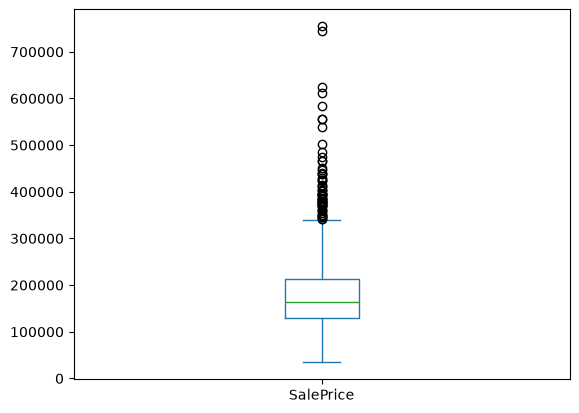

In [20]:
train["SalePrice"].plot(kind="box")

In [21]:
train["SalePrice"].skew()

np.float64(1.8828757597682129)

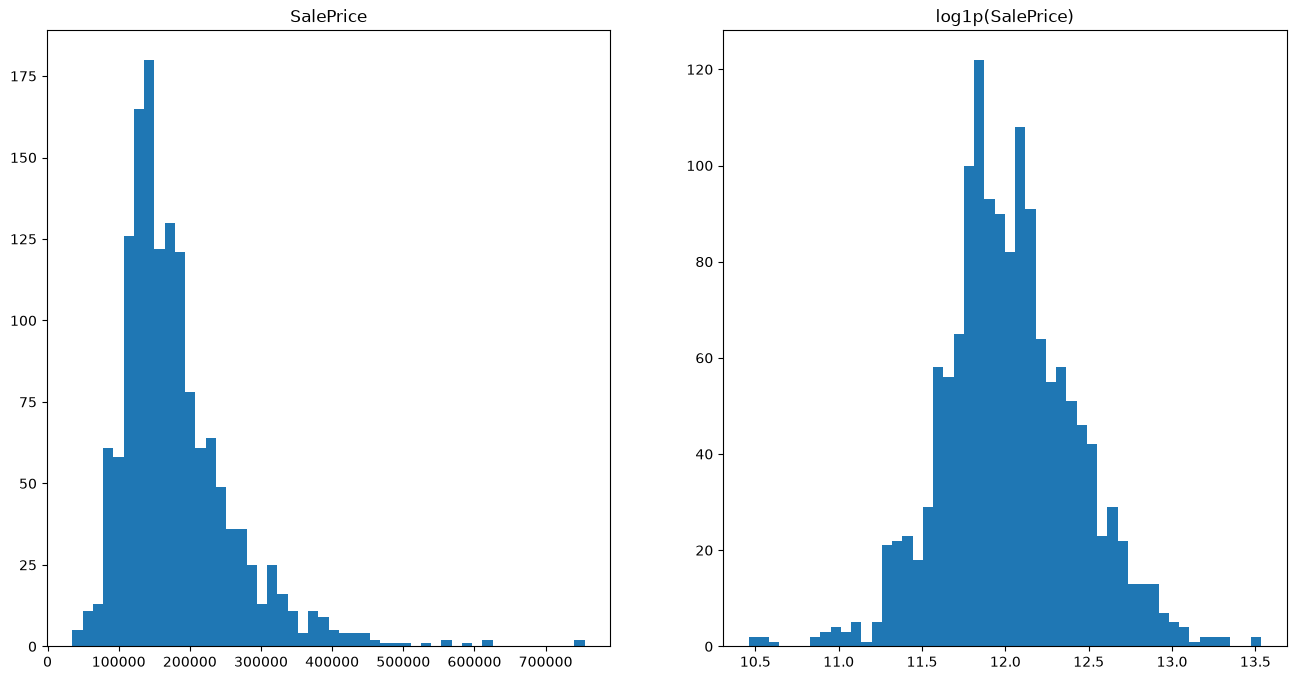

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].hist(train["SalePrice"], bins=50)
axes[0].set_title("SalePrice")

axes[1].hist(np.log1p(train["SalePrice"]), bins=50)
axes[1].set_title("log1p(SalePrice)")

plt.show()

In [23]:
print("orig:", train["SalePrice"].skew())
print("log1p:", np.log1p(train["SalePrice"]).skew())

orig: 1.8828757597682129
log1p: 0.12134661989685329


In [24]:
missing = train.isna().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [25]:
train["PoolQC"].value_counts(dropna=False)

PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64

In [26]:
train.groupby(train["PoolQC"].isna())["PoolArea"].agg(
    ["count", "mean", "median", "max"]
    )

,count,mean,median,max
PoolQC,,,,
False,7,575.428571,555.0,738
True,1453,0.000000,0.0,0


In [27]:
train["GarageType"].value_counts(dropna=False)

GarageType
Attchd     870
Detchd     387
BuiltIn     88
NaN         81
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

In [28]:
train.groupby(train["GarageType"].isna())["GarageCars"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
GarageType,,,,
False,1379,1.870921,2.0,4
True,81,0.000000,0.0,0


In [29]:
garage_cols = [
    "GarageType", "GarageFinish", "GarageQual", "GarageCond", 
    "GarageYrBlt", "GarageCars", "GarageArea"
]

train[garage_cols].isna().sum()

GarageType      81
GarageFinish    81
GarageQual      81
GarageCond      81
GarageYrBlt     81
GarageCars       0
GarageArea       0
dtype: int64

In [30]:
train[train["GarageType"].isna()][garage_cols]

,GarageType,GarageFinish,GarageQual,GarageCond,GarageYrBlt,GarageCars,GarageArea
39,NaN,NaN,NaN,NaN,NaN,0,0
48,NaN,NaN,NaN,NaN,NaN,0,0
78,NaN,NaN,NaN,NaN,NaN,0,0
88,NaN,NaN,NaN,NaN,NaN,0,0
89,NaN,NaN,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...
1349,NaN,NaN,NaN,NaN,NaN,0,0
1407,NaN,NaN,NaN,NaN,NaN,0,0
1449,NaN,NaN,NaN,NaN,NaN,0,0
1450,NaN,NaN,NaN,NaN,NaN,0,0


In [31]:
bsmt_cols = [
    "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "TotalBsmtSF"
]
train[bsmt_cols].isna().sum()

BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
TotalBsmtSF      0
dtype: int64

In [32]:
train[train["BsmtQual"].isna()][bsmt_cols].value_counts()

Series([], Name: count, dtype: int64)

In [33]:
train[train["BsmtQual"].notna()]["TotalBsmtSF"].describe()

count    1423.000000
mean     1084.924104
std       409.413709
min       105.000000
25%       810.500000
50%      1004.000000
75%      1309.500000
max      6110.000000
Name: TotalBsmtSF, dtype: float64

In [34]:
train[train["BsmtExposure"].isna()][bsmt_cols]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,TotalBsmtSF
17,NaN,NaN,NaN,NaN,NaN,0
39,NaN,NaN,NaN,NaN,NaN,0
90,NaN,NaN,NaN,NaN,NaN,0
102,NaN,NaN,NaN,NaN,NaN,0
156,NaN,NaN,NaN,NaN,NaN,0
182,NaN,NaN,NaN,NaN,NaN,0
259,NaN,NaN,NaN,NaN,NaN,0
342,NaN,NaN,NaN,NaN,NaN,0
362,NaN,NaN,NaN,NaN,NaN,0
371,NaN,NaN,NaN,NaN,NaN,0


In [35]:
train["MasVnrType"].value_counts(dropna=False)

MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [36]:
train.groupby(train["MasVnrType"].isna())["MasVnrArea"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
MasVnrType,,,,
False,588,254.430272,202.5,1600.0
True,864,1.094907,0.0,344.0


In [37]:
train[train["MasVnrType"].isna() & (train["MasVnrArea"] >0)][[
    "MasVnrType", "MasVnrArea", "OverallQual", "Neighborhood", "SalePrice"
]]

,MasVnrType,MasVnrArea,OverallQual,Neighborhood,SalePrice
624,NaN,288.0,6,NWAmes,165150
773,NaN,1.0,5,NAmes,114500
1230,NaN,1.0,5,Sawyer,190000
1300,NaN,344.0,7,Gilbert,225000
1334,NaN,312.0,5,BrDale,125000


In [38]:
train[train["LotFrontage"].isna()][[
    "LotFrontage", "LotArea", "Neighborhood", "SalePrice"
]].head(20)


,LotFrontage,LotArea,Neighborhood,SalePrice
7,NaN,10382,NWAmes,200000
12,NaN,12968,Sawyer,144000
14,NaN,10920,NAmes,157000
16,NaN,11241,NAmes,149000
24,NaN,8246,Sawyer,154000
31,NaN,8544,Sawyer,149350
42,NaN,9180,SawyerW,144000
43,NaN,9200,CollgCr,130250
50,NaN,13869,Gilbert,177000
64,NaN,9375,CollgCr,219500


In [39]:
train.groupby("Neighborhood")["LotFrontage"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Neighborhood,,,
Blmngtn,14,47.142857,43.0
Blueste,2,24.000000,24.0
BrDale,16,21.562500,21.0
BrkSide,51,57.509804,52.0
ClearCr,13,83.461538,80.0
CollgCr,126,71.682540,70.0
Crawfor,41,71.804878,74.0
Edwards,92,68.217391,65.5
Gilbert,49,79.877551,65.0


In [40]:
train[train["Electrical"].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,1380,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [41]:
maybe_ordinal = [
    "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "GarageFinish", "Functional", "PavedDrive",
    "LotShape", "Utilities", "LandSlope"
    ]
for col in maybe_ordinal:
    print(f"\n{col}")
    print(train[col].value_counts(dropna=False))


BsmtExposure
BsmtExposure
No     953
Av     221
Gd     134
Mn     114
NaN     38
Name: count, dtype: int64

BsmtFinType1
BsmtFinType1
Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
NaN     37
Name: count, dtype: int64

BsmtFinType2
BsmtFinType2
Unf    1256
Rec      54
LwQ      46
NaN      38
BLQ      33
ALQ      19
GLQ      14
Name: count, dtype: int64

GarageFinish
GarageFinish
Unf    605
RFn    422
Fin    352
NaN     81
Name: count, dtype: int64

Functional
Functional
Typ     1360
Min2      34
Min1      31
Mod       15
Maj1      14
Maj2       5
Sev        1
Name: count, dtype: int64

PavedDrive
PavedDrive
Y    1340
N      90
P      30
Name: count, dtype: int64

LotShape
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

Utilities
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

LandSlope
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64


In [42]:
cat_stats = pd.DataFrame({
    "n_unique": train[cat_cols].nunique(),
    "n_missing": train[cat_cols].isna().sum()
}).sort_values("n_unique", ascending=False)

cat_stats

,n_unique,n_missing
Neighborhood,25,0
Exterior2nd,16,0
Exterior1st,15,0
SaleType,9,0
Condition1,9,0
Condition2,8,0
HouseStyle,8,0
RoofMatl,8,0
Functional,7,0
BsmtFinType2,6,38


In [43]:
cols = [
    "ExterQual",
    "KitchenQual",
    "BsmtQual",
    "GarageFinish",
    "Neighborhood",
    "BsmtFinType1",
    "Functional"
]
for col in cols:
    print(train.groupby(col)["SalePrice"].agg(["count", "mean", "median"]))

           count           mean    median
ExterQual                                
Ex            52  367360.961538  364606.5
Fa            14   87985.214286   82250.0
Gd           488  231633.510246  220000.0
TA           906  144341.313466  139450.0
             count           mean    median
KitchenQual                                
Ex             100  328554.670000  316750.0
Fa              39  105565.205128  115000.0
Gd             586  212116.023891  201400.0
TA             735  139962.511565  137000.0
          count           mean    median
BsmtQual                                
Ex          121  327041.041322  318000.0
Fa           35  115692.028571  112000.0
Gd          618  202688.478964  192070.0
TA          649  140759.818182  135500.0
              count           mean    median
GarageFinish                                
Fin             352  240052.690341  215000.0
RFn             422  202068.869668  190000.0
Unf             605  142156.423140  135000.0
             

In [44]:
for col in ["Alley", "Fence", "MiscFeature", "FireplaceQu"]:
    print(train.groupby(col, dropna=False)["SalePrice"].agg(["count", "mean", "median"]))
    print()

       count           mean    median
Alley                                
Grvl      50  122219.080000  119500.0
Pave      41  168000.585366  172500.0
NaN     1369  183452.131483  165000.0

       count           mean    median
Fence                                
GdPrv     59  178927.457627  167500.0
GdWo      54  140379.314815  138750.0
MnPrv    157  148751.089172  137450.0
MnWw      11  134286.363636  130000.0
NaN     1179  187596.837998  173000.0

             count           mean    median
MiscFeature                                
Gar2             2  170750.000000  170750.0
Othr             2   94000.000000   94000.0
Shed            49  151187.612245  144000.0
TenC             1  250000.000000  250000.0
NaN           1406  182046.410384  164250.0

             count           mean    median
FireplaceQu                                
Ex              24  337712.500000  314250.0
Fa              33  167298.484848  158000.0
Gd             380  226351.415789  206950.0
Po           

In [45]:
corr = train.select_dtypes(include="number").corr()
high_corr = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(key=abs, ascending=False))
high_corr[abs(high_corr) > 0.6]

GarageCars    GarageArea      0.882475
YearBuilt     GarageYrBlt     0.825667
GrLivArea     TotRmsAbvGrd    0.825489
TotalBsmtSF   1stFlrSF        0.819530
OverallQual   SalePrice       0.790982
GrLivArea     SalePrice       0.708624
2ndFlrSF      GrLivArea       0.687501
BedroomAbvGr  TotRmsAbvGrd    0.676620
BsmtFinSF1    BsmtFullBath    0.649212
YearRemodAdd  GarageYrBlt     0.642277
GarageCars    SalePrice       0.640409
GrLivArea     FullBath        0.630012
GarageArea    SalePrice       0.623431
2ndFlrSF      TotRmsAbvGrd    0.616423
TotalBsmtSF   SalePrice       0.613581
2ndFlrSF      HalfBath        0.609707
1stFlrSF      SalePrice       0.605852
OverallQual   GarageCars      0.600671
dtype: float64

In [46]:
cols = [
    "LotArea",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "GarageArea",
    "SalePrice"
]
train[cols].describe(percentiles=[.01, .05, .95, .99]).T

,count,mean,std,min,1%,5%,95%,99%,max
LotArea,1460.0,10516.828082,9981.264932,1300.0,1680.00,3311.70,17401.15,37567.64,215245.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,692.18,848.00,2466.10,3123.48,5642.0
TotalBsmtSF,1460.0,1057.429452,438.705324,0.0,0.00,519.30,1753.00,2155.05,6110.0
1stFlrSF,1460.0,1162.626712,386.587738,334.0,520.00,672.95,1831.25,2219.46,4692.0
GarageArea,1460.0,472.980137,213.804841,0.0,0.00,0.00,850.10,1002.79,1418.0
SalePrice,1460.0,180921.195890,79442.502883,34900.0,61815.97,88000.00,326100.00,442567.01,755000.0


In [47]:
for col in cols:
    threshold = train[col].quantile(0.99)
    print(col, threshold, (train[col] > threshold).sum())

LotArea 37567.64000000021 15
GrLivArea 3123.4800000000023 15
TotalBsmtSF 2155.05 15
1stFlrSF 2219.4600000000005 15
GarageArea 1002.7900000000016 15
SalePrice 442567.01000000053 15


In [48]:
train.nlargest(15, "GrLivArea")[[ 
    "GrLivArea",
    "OverallQual",
    "OverallCond",
    "Neighborhood",
    "YearBuilt",
    "TotalBsmtSF",
    "GarageCars",
    "SalePrice"
]].sort_values("SalePrice")

,GrLivArea,OverallQual,OverallCond,Neighborhood,YearBuilt,TotalBsmtSF,GarageCars,SalePrice
1298,5642,10,5,Edwards,2008,6110,2,160000
523,4676,10,5,Edwards,2007,3138,3,184750
635,3395,6,7,SWISU,1914,1440,0,200000
304,3493,7,9,OldTown,1880,1470,3,295000
118,3222,7,5,SawyerW,1990,1673,3,320000
608,3194,8,6,Crawfor,1934,965,2,359100
1268,3447,8,9,Crawfor,1935,728,3,381000
1353,3238,8,5,NoRidge,1995,2033,3,410000
496,3228,8,5,NoRidge,1992,3200,2,430000
185,3608,10,9,OldTown,1892,1107,3,475000


In [49]:
train[train["OverallQual"] == 10][[
    "GrLivArea",
    "Neighborhood",
    "YearBuilt",
    "TotalBsmtSF",
    "GarageCars",
    "SalePrice"
]].sort_values("SalePrice")

,GrLivArea,Neighborhood,YearBuilt,TotalBsmtSF,GarageCars,SalePrice
1298,5642,Edwards,2008,6110,2,160000
523,4676,Edwards,2007,3138,3,184750
1442,2007,Somerst,2008,1017,3,310000
583,2775,OldTown,1893,1237,2,325000
994,1718,NridgHt,2006,1700,3,337500
825,2084,NridgHt,2007,2078,3,385000
224,2392,NridgHt,2003,2392,3,386250
515,2020,NridgHt,2009,2006,3,402861
389,2332,NridgHt,2007,1682,3,426000
58,2945,StoneBr,2006,1410,3,438780


In [50]:
train["LotArea"].describe(percentiles=[.5, .9, .95, .99, .995])

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
50%        9478.500000
90%       14381.700000
95%       17401.150000
99%       37567.640000
99.5%     53422.285000
max      215245.000000
Name: LotArea, dtype: float64

In [51]:
train.nlargest(15, "LotArea")[
    ["LotArea", "OverallQual", "Neighborhood", "GrLivArea", "SalePrice"]
]

,LotArea,OverallQual,Neighborhood,GrLivArea,SalePrice
313,215245,7,Timber,2036,375000
335,164660,5,Timber,1786,228950
249,159000,6,ClearCr,2144,277000
706,115149,7,ClearCr,1824,302000
451,70761,7,ClearCr,1533,280000
1298,63887,10,Edwards,5642,160000
1396,57200,5,Timber,1687,160000
769,53504,8,StoneBr,3279,538000
457,53227,4,ClearCr,1663,256000
384,53107,6,ClearCr,1953,240000


In [52]:
print("orig:", train["LotArea"].skew())
print("log1p", np.log1p(train["LotArea"]).skew())

orig: 12.207687851233496
log1p -0.13740448122837784


In [53]:
cols = train.select_dtypes(include="number").columns
train[cols].drop(columns="SalePrice").skew().sort_values(ascending=False)

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
Id                0.000000
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
GarageYrBlt      -0.649415
d

In [54]:
cols = [
    "LotArea",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "BsmtFinSF1",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "ScreenPorch",
    "3SsnPorch"
]
for col in cols:
    print(f"{col} orig:", train[col].skew())
    print(f"{col} log1p:", np.log1p(train[col]).skew())

LotArea orig: 12.207687851233496
LotArea log1p: -0.13740448122837784
GrLivArea orig: 1.3665603560164552
GrLivArea log1p: -0.006140253486287281
TotalBsmtSF orig: 1.5242545490627664
TotalBsmtSF log1p: -5.1546699835179135
1stFlrSF orig: 1.3767566220336365
1stFlrSF log1p: 0.08011408968181778
BsmtFinSF1 orig: 1.685503071910789
BsmtFinSF1 log1p: -0.618409817855514
WoodDeckSF orig: 1.5413757571931312
WoodDeckSF log1p: 0.15353659020909782
OpenPorchSF orig: 2.3643417403694404
OpenPorchSF log1p: -0.02339729485739231
EnclosedPorch orig: 3.08987190371177
EnclosedPorch log1p: 2.1122749483873156
ScreenPorch orig: 4.122213743143115
ScreenPorch log1p: 3.150408862444581
3SsnPorch orig: 10.304342032693112
3SsnPorch log1p: 7.734974870241933


In [55]:
for col in cols:
    print(f"{col} orig to SalePrice:", train[col].corr(train["SalePrice"]))
    print(f"{col} log1p to SalePrice:", np.log1p(train[col]).corr(train["SalePrice"]))

LotArea orig to SalePrice: 0.2638433538714056
LotArea log1p to SalePrice: 0.38852838242409893
GrLivArea orig to SalePrice: 0.7086244776126523
GrLivArea log1p to SalePrice: 0.6951473252879432
TotalBsmtSF orig to SalePrice: 0.6135805515591953
TotalBsmtSF log1p to SalePrice: 0.32588291811594966
1stFlrSF orig to SalePrice: 0.6058521846919149
1stFlrSF log1p to SalePrice: 0.5912990620354681
BsmtFinSF1 orig to SalePrice: 0.3864198062421533
BsmtFinSF1 log1p to SalePrice: 0.18547188069922277
WoodDeckSF orig to SalePrice: 0.3244134445681298
WoodDeckSF log1p to SalePrice: 0.3214499750681848
OpenPorchSF orig to SalePrice: 0.31585622711605527
OpenPorchSF log1p to SalePrice: 0.4299702130036535
EnclosedPorch orig to SalePrice: -0.12857795792595678
EnclosedPorch log1p to SalePrice: -0.1760645402161489
ScreenPorch orig to SalePrice: 0.1114465711429112
ScreenPorch log1p to SalePrice: 0.09391002563255571
3SsnPorch orig to SalePrice: 0.04458366533574841
3SsnPorch log1p to SalePrice: 0.04732182740491534


In [56]:
print(train["MSSubClass"].value_counts().sort_index())
print(train.groupby("MSSubClass")["SalePrice"].agg(["count", "mean", "median"]))

MSSubClass
20     536
30      69
40       4
45      12
50     144
60     299
70      60
75      16
80      58
85      20
90      52
120     87
160     63
180     10
190     30
Name: count, dtype: int64
            count           mean    median
MSSubClass                                
20            536  185224.811567  159250.0
30             69   95829.724638   99900.0
40              4  156125.000000  142500.0
45             12  108591.666667  107500.0
50            144  143302.972222  132000.0
60            299  239948.501672  215200.0
70             60  166772.416667  156000.0
75             16  192437.500000  163500.0
80             58  169736.551724  166500.0
85             20  147810.000000  140750.0
90             52  133541.076923  135980.0
120            87  200779.080460  192000.0
160            63  138647.380952  146000.0
180            10  102300.000000   88500.0
190            30  129613.333333  128250.0


In [57]:
print("pearson:",train.corr(numeric_only=True)["LotFrontage"].nlargest(10))
print("spearman:",train.corr(numeric_only=True, method="spearman")["LotFrontage"].nlargest(10))

pearson: LotFrontage     1.000000
1stFlrSF        0.457181
LotArea         0.426095
GrLivArea       0.402797
TotalBsmtSF     0.392075
TotRmsAbvGrd    0.352096
SalePrice       0.351799
GarageArea      0.344997
GarageCars      0.285691
Fireplaces      0.266639
Name: LotFrontage, dtype: float64
spearman: LotFrontage     1.000000
LotArea         0.649633
1stFlrSF        0.427678
SalePrice       0.409076
TotalBsmtSF     0.386206
GarageArea      0.378052
GrLivArea       0.375844
TotRmsAbvGrd    0.365999
GarageCars      0.351756
BedroomAbvGr    0.327679
Name: LotFrontage, dtype: float64


<Axes: xlabel='LotArea', ylabel='LotFrontage'>

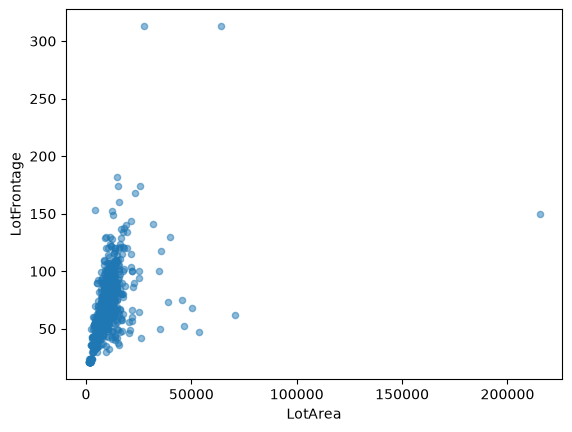

In [58]:
train.plot.scatter(x="LotArea", y="LotFrontage", alpha=0.5)

In [59]:
train.groupby("Neighborhood")["LotFrontage"].agg(["count", "mean", "median"]).sort_values("median")

,count,mean,median
Neighborhood,,,
BrDale,16,21.562500,21.0
MeadowV,15,27.800000,21.0
Blueste,2,24.000000,24.0
NPkVill,7,32.285714,24.0
Blmngtn,14,47.142857,43.0
BrkSide,51,57.509804,52.0
SWISU,23,58.913043,60.0
IDOTRR,34,62.500000,60.0
OldTown,109,62.788991,60.0


In [60]:
print(train.groupby("Neighborhood")[["LotFrontage", "LotArea"]].corr())

                          LotFrontage   LotArea
Neighborhood                                   
Blmngtn      LotFrontage     1.000000  0.966360
             LotArea         0.966360  1.000000
Blueste      LotFrontage          NaN       NaN
             LotArea              NaN  1.000000
BrDale       LotFrontage     1.000000  0.768490
             LotArea         0.768490  1.000000
BrkSide      LotFrontage     1.000000  0.726889
             LotArea         0.726889  1.000000
ClearCr      LotFrontage     1.000000 -0.436136
             LotArea        -0.436136  1.000000
CollgCr      LotFrontage     1.000000  0.350538
             LotArea         0.350538  1.000000
Crawfor      LotFrontage     1.000000  0.628756
             LotArea         0.628756  1.000000
Edwards      LotFrontage     1.000000  0.861987
             LotArea         0.861987  1.000000
Gilbert      LotFrontage     1.000000  0.377790
             LotArea         0.377790  1.000000
IDOTRR       LotFrontage     1.000000  0

# Test block preprocess

In [ ]:

from data import get_feat_groups, preprocessing, gen_features
groups = get_feat_groups(train)

print("numeric", groups["numeric"])
print("ordinal", groups["ordinal"])
print("nominal", groups["nominal"])

numeric ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
ordinal ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'GarageQual', 'GarageCond', 'PoolQC', 'FireplaceQu', 'BsmtExposure', 'GarageFinish', 'LotShape', 'LandSlope', 'PavedDrive']
nominal ['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'El

In [62]:
print(set(train.columns) - (
    set(groups["numeric"])
    | set(groups["ordinal"])
    | set(groups["nominal"])
))
print(set(groups["numeric"]) & set(groups["ordinal"]))
print(set(groups["numeric"]) & set(groups["nominal"]))
print(set(groups["ordinal"]) & set(groups["nominal"]))

{'Id', 'SalePrice'}
set()
set()
set()


In [63]:
train_prep = preprocessing(train)
test_prep = preprocessing(test)
train_prep[groups["ordinal"]].dtypes

ExterQual       int64
ExterCond       int64
BsmtQual        int64
BsmtCond        int64
HeatingQC       int64
KitchenQual     int64
GarageQual      int64
GarageCond      int64
PoolQC          int64
FireplaceQu     int64
BsmtExposure    int64
GarageFinish    int64
LotShape        int64
LandSlope       int64
PavedDrive      int64
dtype: object

In [64]:
train_prep.isna().sum().sort_values(ascending=False).head(20)

Id              0
CentralAir      0
GarageYrBlt     0
GarageType      0
FireplaceQu     0
Fireplaces      0
Functional      0
TotRmsAbvGrd    0
KitchenQual     0
KitchenAbvGr    0
BedroomAbvGr    0
HalfBath        0
FullBath        0
BsmtHalfBath    0
BsmtFullBath    0
GrLivArea       0
LowQualFinSF    0
2ndFlrSF        0
1stFlrSF        0
GarageFinish    0
dtype: int64

In [65]:
train_prep[groups["ordinal"]].head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,GarageQual,GarageCond,PoolQC,FireplaceQu,BsmtExposure,GarageFinish,LotShape,LandSlope,PavedDrive
0,4,3,4,3,5,4,3,3,0,0,1,2,4,1,2
1,3,3,4,3,5,3,3,3,0,3,4,2,4,1,2
2,4,3,4,3,5,4,3,3,0,3,2,2,3,1,2
3,3,3,3,4,4,4,3,3,0,4,1,1,3,1,2
4,4,3,4,3,5,4,3,3,0,3,3,2,3,1,2


In [66]:
train_prep[groups["ordinal"]].describe()

,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,GarageQual,GarageCond,PoolQC,FireplaceQu,BsmtExposure,GarageFinish,LotShape,LandSlope,PavedDrive
count,1460.00000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,3.39589,3.083562,3.489041,2.934932,4.145205,3.511644,2.810274,2.808904,0.017808,1.825342,1.630137,1.715753,3.591781,1.062329,1.856164
std,0.57428,0.351054,0.876478,0.552159,0.959501,0.663760,0.722898,0.719685,0.268952,1.810877,1.067391,0.892831,0.582296,0.276232,0.496592
min,2.00000,1.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000,1.000000,1.000000,3.000000,1.000000,2.000000
50%,3.00000,3.000000,4.000000,3.000000,5.000000,3.000000,3.000000,3.000000,0.000000,2.000000,1.000000,2.000000,4.000000,1.000000,2.000000
75%,4.00000,3.000000,4.000000,3.000000,5.000000,4.000000,3.000000,3.000000,0.000000,4.000000,2.000000,2.000000,4.000000,1.000000,2.000000
max,5.00000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,3.000000,4.000000,3.000000,2.000000


In [67]:
before = train[groups["ordinal"]].isna().sum()
after = train_prep[groups["ordinal"]].isna().sum()

pd.concat([before, after], axis=1, keys=["before", "after"])

,before,after
ExterQual,0,0
ExterCond,0,0
BsmtQual,37,0
BsmtCond,37,0
HeatingQC,0,0
KitchenQual,0,0
GarageQual,81,0
GarageCond,81,0
PoolQC,1453,0
FireplaceQu,690,0


In [68]:
train_prep.isna().sum().sort_values(ascending=False).head()

Id             0
CentralAir     0
GarageYrBlt    0
GarageType     0
FireplaceQu    0
dtype: int64

In [69]:
train_prep["MasVnrType"].value_counts(dropna=False)

MasVnrType
None       869
BrkFace    444
Stone      127
BrkCmn      15
Unknown      5
Name: count, dtype: int64

In [70]:
train_prep.groupby("Neighborhood")["LotFrontage"].median()

Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    52.0
ClearCr    80.0
CollgCr    70.0
Crawfor    74.0
Edwards    65.5
Gilbert    65.0
IDOTRR     60.0
MeadowV    21.0
Mitchel    73.0
NAmes      73.0
NPkVill    24.0
NWAmes     80.0
NoRidge    91.0
NridgHt    88.5
OldTown    60.0
SWISU      60.0
Sawyer     71.0
SawyerW    66.5
Somerst    73.5
StoneBr    61.5
Timber     85.0
Veenker    68.0
Name: LotFrontage, dtype: float64

# Feature engineering

In [71]:
diff = train["GrLivArea"] - (train["1stFlrSF"] + train["2ndFlrSF"])
print(diff.describe())
print("There is a diff:",(diff != 0).sum())

count    1460.000000
mean        5.844521
std        48.623081
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       572.000000
dtype: float64
There is a diff: 26


In [72]:
diff.value_counts().head()

0      1434
80        3
360       2
513       1
234       1
Name: count, dtype: int64

In [73]:
train.loc[diff != 0,[
    "GrLivArea", "1stFlrSF", "2ndFlrSF", "TotalBsmtSF",
     "OverallQual", "Neighborhood", "SalePrice"
]]

,GrLivArea,1stFlrSF,2ndFlrSF,TotalBsmtSF,OverallQual,Neighborhood,SalePrice
51,1176,816,0,816,6,BrkSide,114500
88,1526,1013,0,1013,3,IDOTRR,85000
125,754,520,0,520,6,IDOTRR,84500
170,1382,854,0,720,5,OldTown,128500
185,3608,1518,1518,1107,10,OldTown,475000
187,1656,808,704,660,5,OldTown,135000
197,3112,1360,1360,1360,8,NAmes,235000
198,2229,929,929,755,6,OldTown,104000
263,1316,926,0,926,5,OldTown,130000
267,2192,1052,720,720,5,SWISU,179500


In [74]:
train["TotalSF"] = train["GrLivArea"] + train["TotalBsmtSF"]

train[["TotalSF", "GrLivArea", "TotalBsmtSF", "SalePrice"]].corr()

,TotalSF,GrLivArea,TotalBsmtSF,SalePrice
TotalSF,1.000000,0.880324,0.822888,0.778959
GrLivArea,0.880324,1.000000,0.454868,0.708624
TotalBsmtSF,0.822888,0.454868,1.000000,0.613581
SalePrice,0.778959,0.708624,0.613581,1.000000


In [75]:
train["TotalPorchSF"] = (
    train["WoodDeckSF"]
    + train["OpenPorchSF"]
    + train["EnclosedPorch"]
    + train["3SsnPorch"]
    + train["ScreenPorch"]
)
train[[
        "TotalPorchSF",
        "WoodDeckSF",
        "OpenPorchSF",
        "EnclosedPorch",
        "3SsnPorch",
        "ScreenPorch",
        "SalePrice",
    ]].corr()["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
TotalPorchSF     0.390993
WoodDeckSF       0.324413
OpenPorchSF      0.315856
ScreenPorch      0.111447
3SsnPorch        0.044584
EnclosedPorch   -0.128578
Name: SalePrice, dtype: float64

In [76]:
train["HouseAge"] = train["YrSold"] - train["YearBuilt"]
train["RemodAge"] = train["YrSold"] - train["YearRemodAdd"]
train["IsRemod"] = (train["YearRemodAdd"] != train["YearBuilt"]).astype(int)

print(train[["HouseAge", "YearBuilt", "RemodAge", "YearRemodAdd", "IsRemod", "SalePrice"]].corr())
print(train.groupby("IsRemod")["SalePrice"].agg(["count", "mean", "median"]))

              HouseAge  YearBuilt  RemodAge  YearRemodAdd   IsRemod  SalePrice
HouseAge      1.000000  -0.999036  0.594195     -0.590360  0.415201  -0.523350
YearBuilt    -0.999036   1.000000 -0.593868      0.592855 -0.414931   0.522897
RemodAge      0.594195  -0.593868  1.000000     -0.997930 -0.081961  -0.509079
YearRemodAdd -0.590360   0.592855 -0.997930      1.000000  0.083287   0.507101
IsRemod       0.415201  -0.414931 -0.081961      0.083287  1.000000  -0.021933
SalePrice    -0.523350   0.522897 -0.509079      0.507101 -0.021933   1.000000
         count           mean    median
IsRemod                                
0          764  182583.659686  170000.0
1          696  179096.307471  155000.0


In [77]:
train["AvgRoomArea"] = train["GrLivArea"] / train["TotRmsAbvGrd"]
print(train[["AvgRoomArea" ,"GrLivArea", "TotRmsAbvGrd" ,"SalePrice"]].corr())
print("\n",train["AvgRoomArea"].describe())

              AvgRoomArea  GrLivArea  TotRmsAbvGrd  SalePrice
AvgRoomArea      1.000000   0.653820      0.144031   0.540645
GrLivArea        0.653820   1.000000      0.825489   0.708624
TotRmsAbvGrd     0.144031   0.825489      1.000000   0.533723
SalePrice        0.540645   0.708624      0.533723   1.000000

 count    1460.000000
mean      230.905362
std        44.740397
min       120.000000
25%       199.000000
50%       226.500000
75%       256.107143
max       470.166667
Name: AvgRoomArea, dtype: float64


In [78]:
train["TotalBath"] = (
    train["FullBath"]
    + 0.5 * train["HalfBath"]
    + train["BsmtFullBath"]
    + 0.5 * train["BsmtHalfBath"]
)

train[[
    "TotalBath",
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",
    "SalePrice"
]].corr()["SalePrice"].sort_values(ascending=False)

SalePrice       1.000000
TotalBath       0.631731
FullBath        0.560664
HalfBath        0.284108
BsmtFullBath    0.227122
BsmtHalfBath   -0.016844
Name: SalePrice, dtype: float64

# Test block FE

In [ ]:
train_fe = gen_features(train_prep)
train_fe[["TotalSF", "TotalPorchSF", "HouseAge", "RemodAge", "TotalBath", "AvgRoomArea"]].describe()

,TotalSF,TotalPorchSF,HouseAge,RemodAge,TotalBath,AvgRoomArea
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,1057.429452,181.329452,36.547945,22.950000,2.210616,167.324106
std,438.705324,156.656097,30.250152,20.640653,0.785399,65.693580
min,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000
25%,795.750000,45.000000,8.000000,4.000000,2.000000,117.803571
50%,991.500000,164.000000,35.000000,14.000000,2.000000,168.500000
75%,1298.250000,266.000000,54.000000,41.000000,2.500000,211.425000
max,6110.000000,1027.000000,136.000000,60.000000,6.000000,509.166667


In [81]:
train_fe[train_fe["RemodAge"]<0][
    ["YrSold", "YearRemodAdd", "RemodAge"]
]

,YrSold,YearRemodAdd,RemodAge
523,2007,2008,-1


In [82]:
train_fe[train_fe["AvgRoomArea"] == 0][
    ["GrLivArea", "TotRmsAbvGrd", "SalePrice"]
]

,GrLivArea,TotRmsAbvGrd,SalePrice
17,0,6,90000
39,0,6,82000
90,0,4,109900
102,0,8,118964
156,0,5,109500
182,0,7,120000
259,0,4,97000
342,0,6,87500
362,0,7,198500
371,0,7,134432


# Hyperparams tuning

In [1]:
from config import config
from data import load_data, preprocessing, gen_features, get_folds
from train import tune_hyperparams

train_df, test_df = load_data(config)

train_df = preprocessing(train_df)
train_fe = gen_features(train_df)

X = train_fe.drop(columns=[config.general.TARGET])
y = train_fe[config.general.TARGET]

folds = get_folds(X, y, config)

In [2]:
GRID_MODE = True
TO_RUN = {
    "knn": False,
    "tree": False,
    "rf": False,
    "catboost": False,
    "lightgbm": False,
    "xgboost": True,
}

PARAM_GRIDS = {
    "knn": {"model__n_neighbors": [3, 5, 7, 11]},
    "tree": {"model__max_depth": [3, 5, 10, None]},
    "rf": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [4, 5, 6],
        "model__min_samples_leaf": [5, 10,20],
    },
    "catboost": {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.005, 0.01, 0.03],
        "model__depth": [3, 4, 5],
    },
    "lightgbm": {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.005, 0.01, 0.03],
        "model__max_depth": [9, 10, 11],
        # "model__num_leaves": [15, 31, 63],
    },
    "xgboost": {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.005, 0.01, 0.03],
        "model__max_depth": [2, 3, 4],
    },
}

In [3]:
best_params = {}

for model_name, param_grid in PARAM_GRIDS.items():
    if not TO_RUN[model_name]:
        continue

    search = tune_hyperparams(model_name, X, y, folds, config, param_grid, GRID_MODE)

    best_params[model_name] = search.best_params_

    print(f"{model_name}: "f"best_score={search.best_score_:.4f}, "f"best_params={search.best_params_}")

xgboost: best_score=-24173.5520, best_params={'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 400}


# Check results